In [2]:
import matplotlib.pyplot as plt
import numpy as np
import  scipy.stats

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


The maximun of the likehood is located at 0.81481, and the MLE is 0.81567


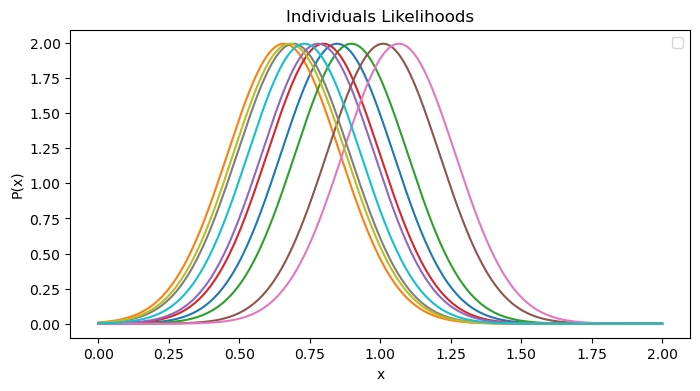

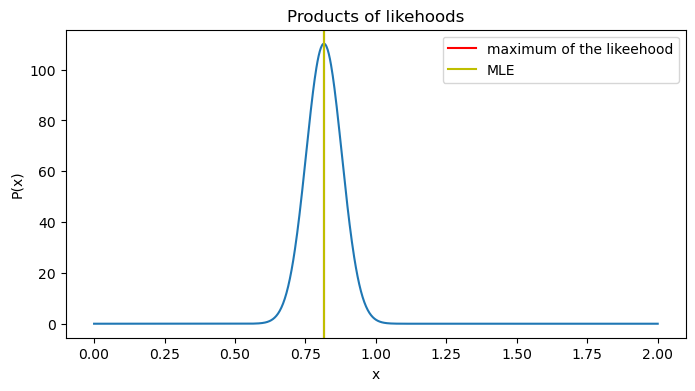

In [27]:
sigma=0.2
N=10
measurements = np.random.normal(loc=1, scale=sigma, size=N)

x_grid = np.linspace(1 - 5 * sigma, 1 + 5 * sigma, 1000)

likelihoods = np.array([scipy.stats.norm.pdf(x_grid, loc=m, scale=sigma) for m in measurements])

plt.figure(figsize=(8, 4))
[plt.plot(x_grid, m) for m in likelihoods]
plt.title("Individuals Likelihoods")
plt.xlabel("x")
plt.ylabel("P(x)")
plt.legend()

product=np.prod(likelihoods, axis=0)

plt.figure(figsize=(8, 4))
plt.plot(x_grid,product)
plt.axvline(x_grid[np.argmax(product)], color='r', label='maximum of the likeehood')
plt.axvline(np.mean(measurements), color='y', label='MLE')
plt.title("Products of likehoods")
plt.xlabel("x")
plt.ylabel("P(x)")
plt.legend()

print(f"The maximun of the likehood is located at {x_grid[np.argmax(product)]:.5f}, and the MLE is {np.mean(measurements):.5f}")

In [101]:
#second point

In [136]:
diff=np.diff(np.log(product), n=2)
diff_norm = -diff/(x_grid[1]-x_grid[0])**2
sigma_pro =  np.sqrt(1/diff_norm)
sigma_final=np.max(sigma_pro)

print(f"The error of the mean estimate with the fisher matrix is {sigma_final:.5f}")

MLE_sigma=sigma/N**0.5

print(f"The error of the mean is {MLE_sigma:.5f}")

The error of the mean estimate with the fisher matrix is 0.06325
The error of the mean is 0.06325


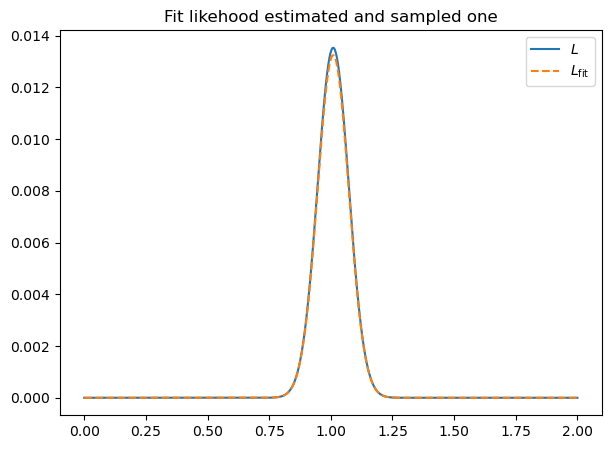

In [149]:
from scipy.stats import norm

Gaussian_2 = norm.pdf(x_grid,loc=np.mean(measurements),scale=MLE_sigma)  

fig, ax = plt.subplots(figsize=(7, 5))

plt.plot(x_grid, product , ls='-', label=r'$L$')

C = 0.0021 #by guess
plt.plot(x_grid, C*Gaussian_2, ls='dashed', label=r'$L_\mathrm{fit}$')

plt.title("Fit likehood estimated and sampled one")
plt.legend()